# Notebook Settings

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

## Import Data

In [18]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 

df = X.copy()
df["y"] = y

In [31]:
df["y"].info()

<class 'pandas.Series'>
RangeIndex: 45211 entries, 0 to 45210
Series name: y
Non-Null Count  Dtype
--------------  -----
45211 non-null  str  
dtypes: str(1)
memory usage: 353.3 KB


In [32]:
df["y_binary"] = (df["y"] == "yes").astype(int)

## Data information

## Bank Client Dataset — Variable Description


### Data Source
https://archive.ics.uci.edu/dataset/222/bank+marketing

### Input Variables

#### **1. Bank Client Data**

| # | Variable    | Description                       | Type / Values                                                                                                                                                             |
| - | ----------- | --------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1 | `age`       | Client age                        | Numeric                                                                                                                                                                   |
| 2 | `job`       | Type of job                       | Categorical: `admin.`, `unknown`, `unemployed`, `management`, `housemaid`, `entrepreneur`, `student`, `blue-collar`, `self-employed`, `retired`, `technician`, `services` |
| 3 | `marital`   | Marital status                    | Categorical: `married`, `divorced`, `single` <br>*(Note: `divorced` includes widowed)*                                                                                    |
| 4 | `education` | Education level                   | Categorical: `unknown`, `secondary`, `primary`, `tertiary`                                                                                                                |
| 5 | `default`   | Has credit in default?            | Binary: `yes`, `no`                                                                                                                                                       |
| 6 | `balance`   | Average yearly balance (in euros) | Numeric                                                                                                                                                                   |
| 7 | `housing`   | Has a housing loan?               | Binary: `yes`, `no`                                                                                                                                                       |
| 8 | `loan`      | Has a personal loan?              | Binary: `yes`, `no`                                                                                                                                                       |

---

#### **2. Last Contact of the Current Campaign**

| #  | Variable   | Description                        | Type / Values                                     |
| -- | ---------- | ---------------------------------- | ------------------------------------------------- |
| 9  | `contact`  | Contact communication type         | Categorical: `unknown`, `telephone`, `cellular`   |
| 10 | `day`      | Last contact day of the month      | Numeric                                           |
| 11 | `month`    | Last contact month of the year     | Categorical: `jan`, `feb`, `mar`, …, `nov`, `dec` |
| 12 | `duration` | Last contact duration (in seconds) | Numeric                                           |

---

#### **3. Other Campaign Attributes**

| #  | Variable   | Description                                                     | Type / Values                                         |
| -- | ---------- | --------------------------------------------------------------- | ----------------------------------------------------- |
| 13 | `campaign` | Number of contacts during this campaign for the client          | Numeric (includes last contact)                       |
| 14 | `pdays`    | Days since the client was last contacted in a previous campaign | Numeric (`-1` = not previously contacted)             |
| 15 | `previous` | Number of contacts before this campaign                         | Numeric                                               |
| 16 | `poutcome` | Outcome of the previous marketing campaign                      | Categorical: `unknown`, `other`, `failure`, `success` |

---

### Output Variable (Target)

| #  | Variable | Description                                  | Type / Values       |
| -- | -------- | -------------------------------------------- | ------------------- |
| 17 | `y`      | Has the client subscribed to a term deposit? | Binary: `yes`, `no` |

---

## Data Type

In [19]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
dtypes: int64(7), str(9)
memory usage: 5.5 MB


### Conclusion:

### 1. Dataset Overview

* **Volume:** The dataset is substantial, containing **45,211 entries** (rows).
* **Features:** It consists of **16 columns**
* **Data Types:** The data is a mix of **7 numerical** columns (Integers) and **9 categorical** columns (Strings/Objects).

### 2. Data Integrity & Missing Values

The most significant finding from this summary is the presence of missing data in specific columns, which will require handling before analysis:
* **`poutcome` (Previous Outcome):** This column has a critical amount of missing data. Only **8,252** out of 45,211 rows are non-null (**~82% missing**). This likely indicates that the majority of customers were not contacted in a previous campaign.
* **`contact`:** Approximately **29%** of the data is missing (32,191 non-null).
* **`education` & `job`:** These have minor missing values (approx. 4% and 0.6% respectively).

### 3. Variable Composition

* **Demographics:** `age`, `job`, `marital`, `education`.
* **Financial Status:** `default`, `balance`, `housing`, `loan`.
* **Campaign Interaction:** `contact`, `day_of_week`, `month`, `duration`, `campaign`.
* **History:** `pdays`, `previous`, `poutcome`.

## Statistics of the data

In [20]:
X.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Conclusion:

### 1. Customer Demographics (`age`)

* **Range:** Age from **18 to 95 years old**, indicating the bank targets the entire adult population, including retirees.
* **Distribution:** The distribution is relatively normal but slightly right-skewed (mean > median).

### 2. Financial Status (`balance`)

* **High Inequality:** This variable shows extreme skewness. The **mean balance (1,362)** is significantly higher than the **median (448)**.
* **Debt & Wealth:** The values range from a deficit of **-8,019** to a high of **102,127**. 

### 3. Campaign Interaction (`duration`, `campaign`)

* **Call Duration:** The average call lasts about **4.3 minutes (258 seconds)**, but the median is shorter (3 minutes). There are extreme outliers, with the longest call lasting over **1.3 hours (4,918 seconds)**.
* **Contact Frequency:** On average, customers are contacted **2 to 3 times** during this campaign.
    The **max of 63 contacts** for a single client is an extreme anomaly that could be a data error (need to findout).Since 75% of customers are contacted 3 times or fewer, values above 10 could be treated as outliers.

## Target Feature Distribution

<Axes: xlabel='y'>

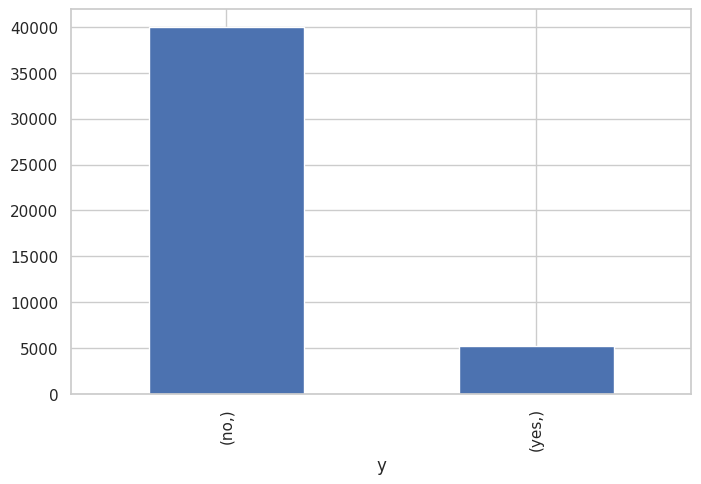

In [24]:
y.value_counts().plot.bar()

In [25]:
target_counts = df["y"].value_counts(normalize=True) * 100
print(target_counts)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


### Conclusion:

The dataset exhibits a severe class imbalance. The number of negative outcomes ("no") vastly outnumbers the positive outcomes ("yes").


## Missing Values

In [22]:
X.isna().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

### Conclusion:


## Age Analysis

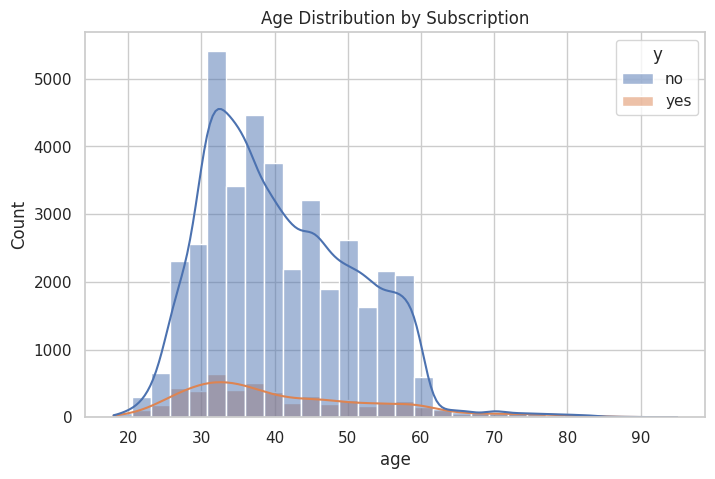

In [26]:
sns.histplot(data=df, x="age", hue="y", bins=30, kde=True)
plt.title("Age Distribution by Subscription")
plt.show()

### Conclusion:



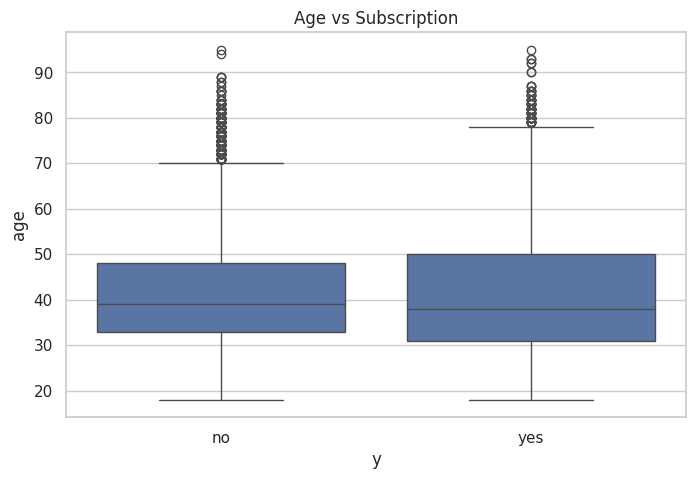

In [27]:
sns.boxplot(data=df, x="y", y="age")
plt.title("Age vs Subscription")
plt.show()

## Categorical Demographics

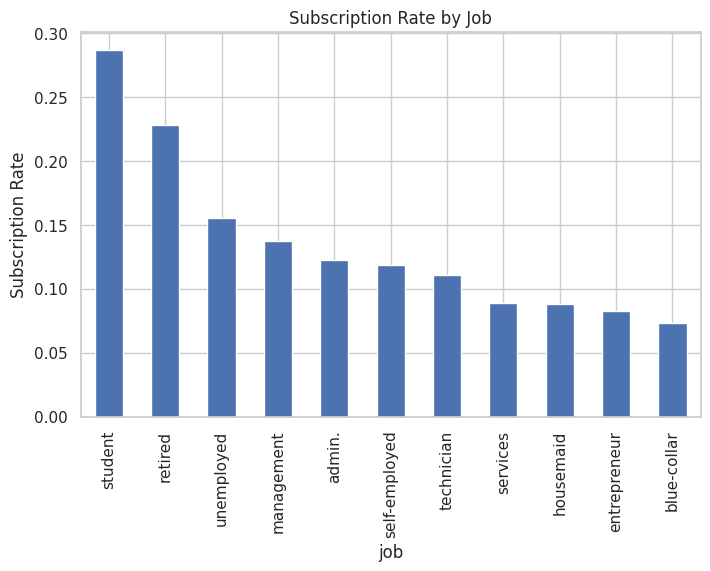

In [33]:
job_rate = (
    df.groupby("job")["y_binary"]
    .mean()
    .sort_values(ascending=False)
)

job_rate.plot(kind="bar")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Job")
plt.show()


## Martial and Education

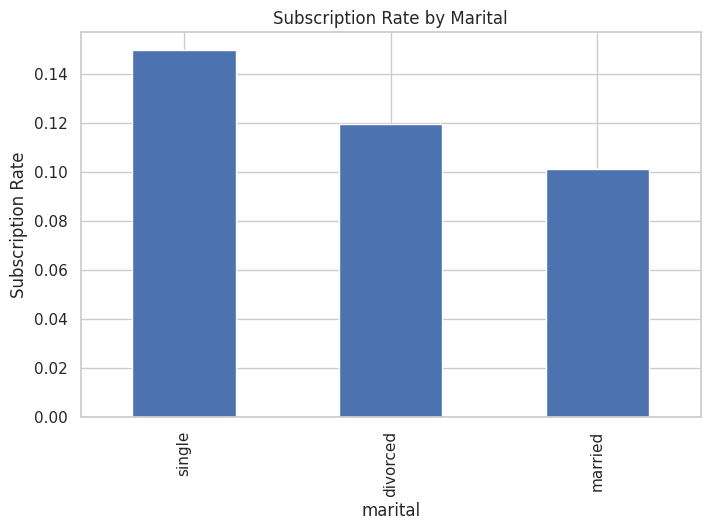

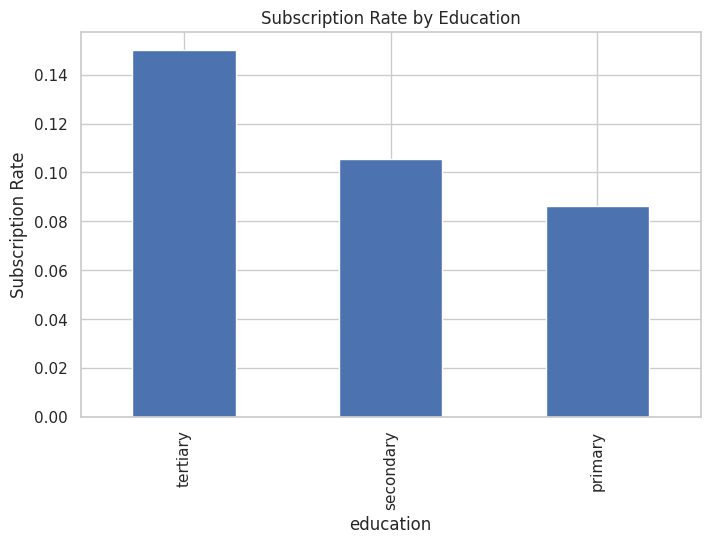

In [34]:
for col in ["marital", "education"]:
    rate = df.groupby(col)["y_binary"].mean().sort_values(ascending=False)
    rate.plot(kind="bar")
    plt.title(f"Subscription Rate by {col.capitalize()}")
    plt.ylabel("Subscription Rate")
    plt.show()


## Financial Features

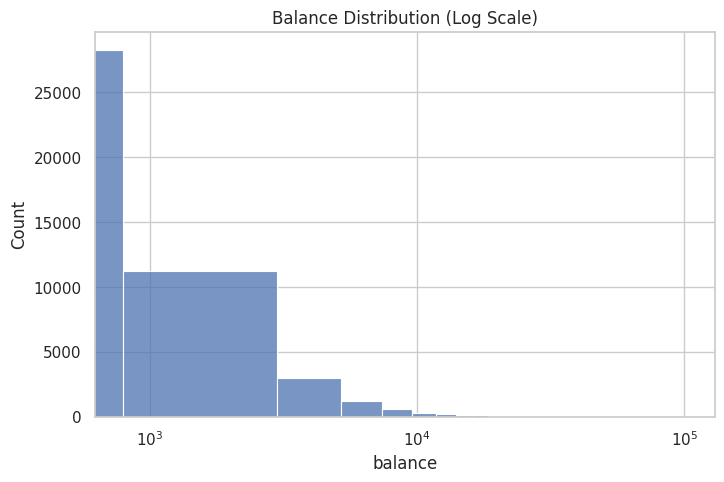

In [35]:
sns.histplot(data=df, x="balance", bins=50)
plt.xscale("log")
plt.title("Balance Distribution (Log Scale)")
plt.show()


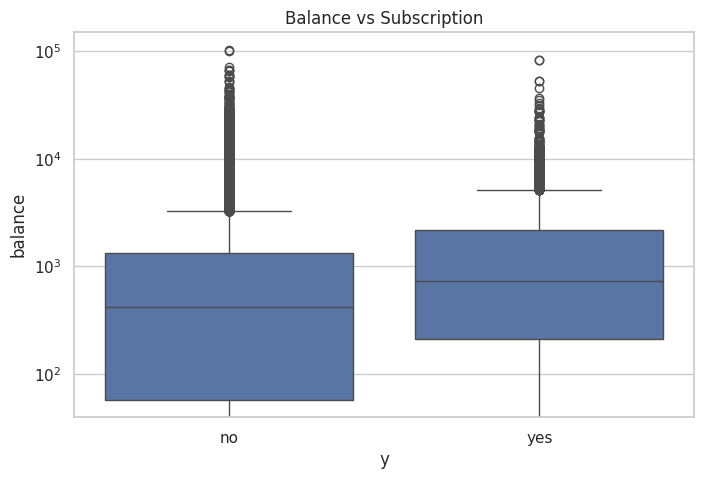

In [36]:
sns.boxplot(data=df, x="y", y="balance")
plt.yscale("log")
plt.title("Balance vs Subscription")
plt.show()

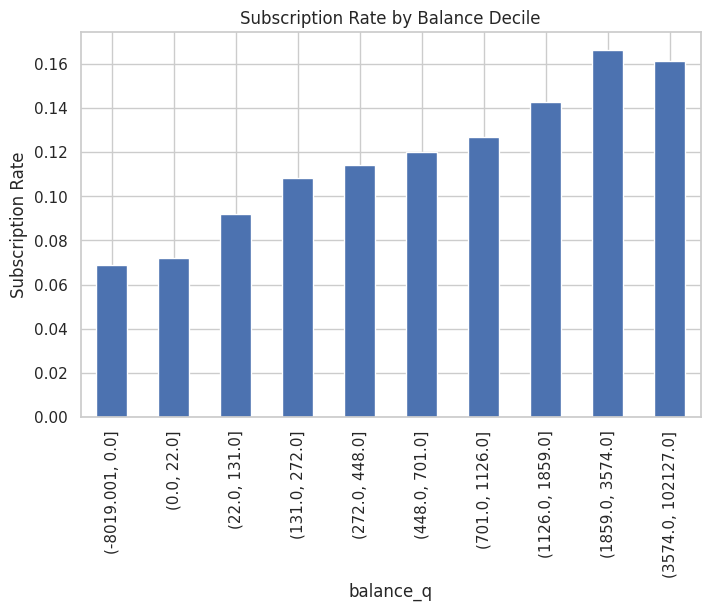

In [37]:
df["balance_q"] = pd.qcut(df["balance"], 10, duplicates="drop")
balance_rate = df.groupby("balance_q")["y_binary"].mean()

balance_rate.plot(kind="bar")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Balance Decile")
plt.show()


## Loan and Default Indicators

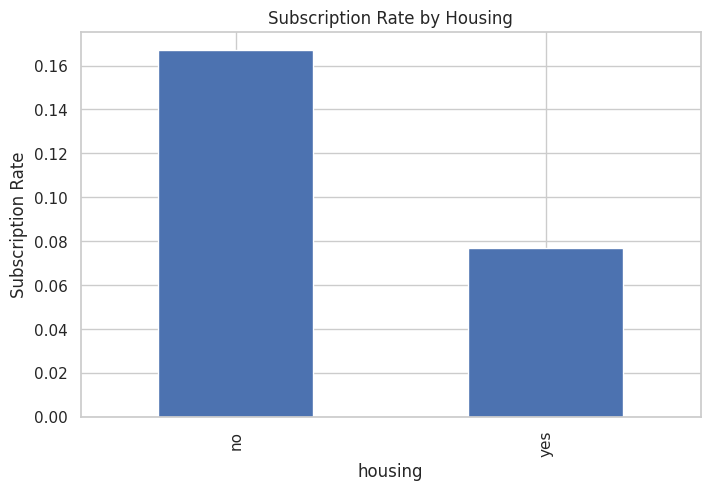

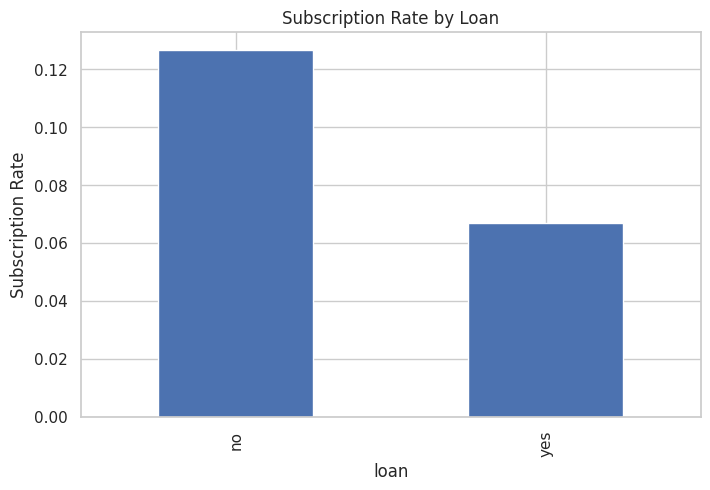

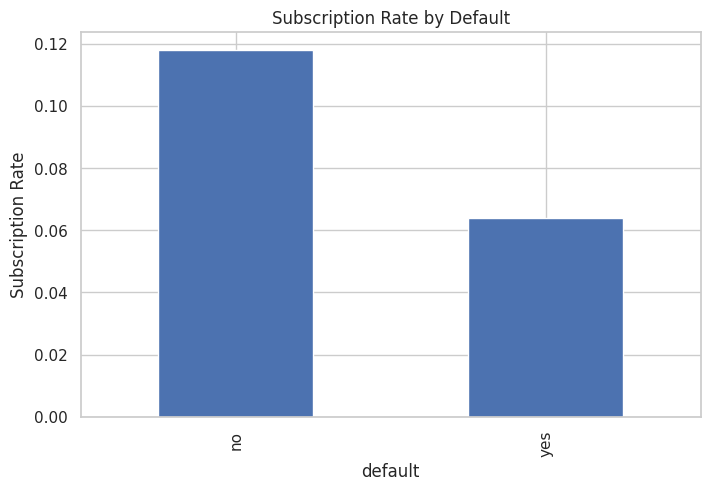

In [38]:
for col in ["housing", "loan", "default"]:
    rate = df.groupby(col)["y_binary"].mean()
    rate.plot(kind="bar")
    plt.title(f"Subscription Rate by {col.capitalize()}")
    plt.ylabel("Subscription Rate")
    plt.show()

## Campaign Indication Variables

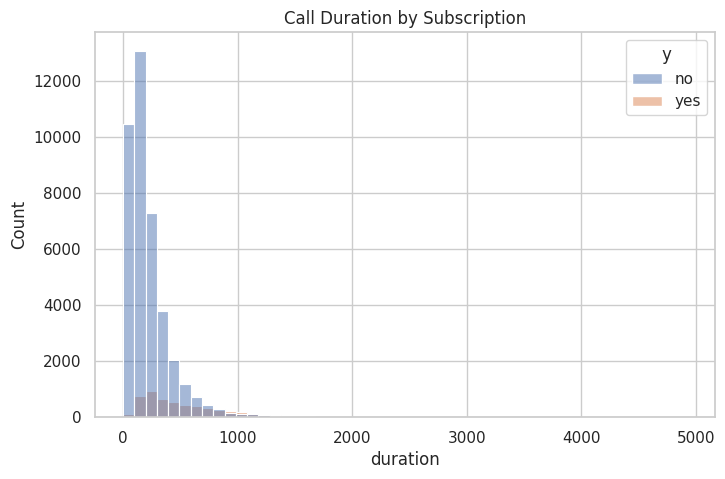

In [42]:
sns.histplot(data=df, x="duration", hue="y", bins=50)
plt.title("Call Duration by Subscription")
plt.show()

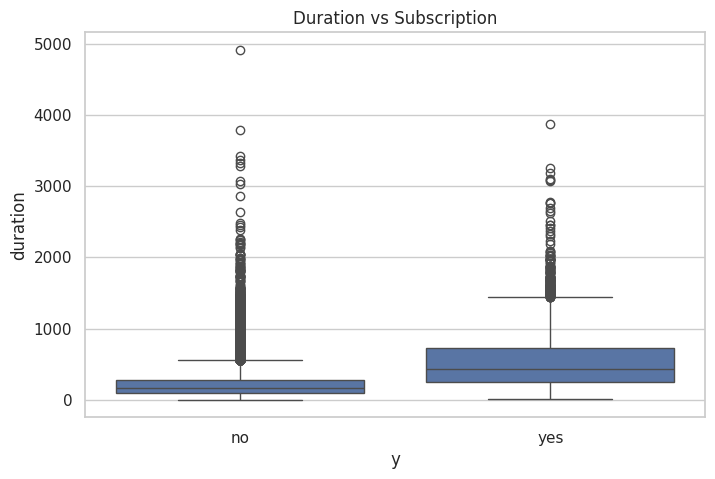

In [43]:
sns.boxplot(data=df, x="y", y="duration")
plt.title("Duration vs Subscription")
plt.show()


## Campaign Count

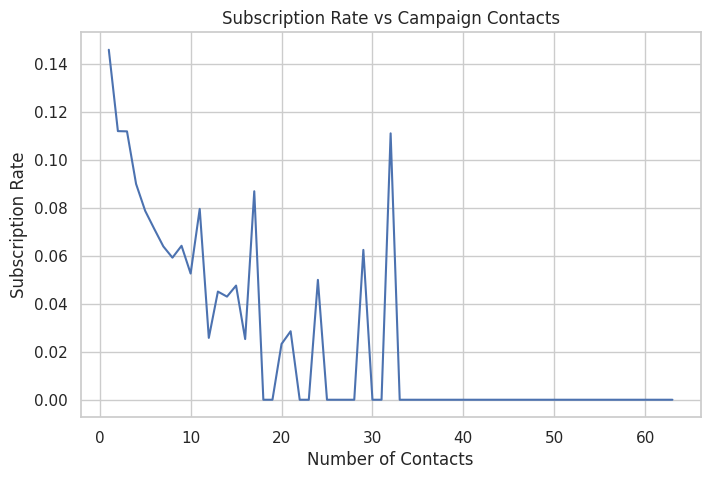

In [44]:
campaign_rate = df.groupby("campaign")["y_binary"].mean()

campaign_rate.plot()
plt.xlabel("Number of Contacts")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate vs Campaign Contacts")
plt.show()


### Previous Contact Info

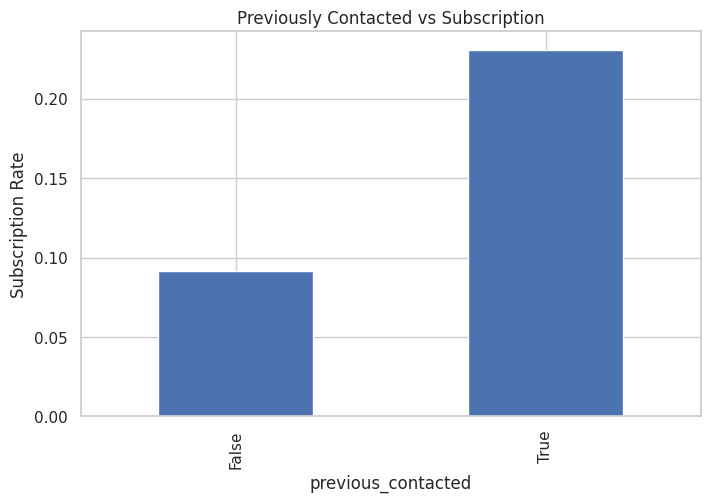

In [45]:
df["previous_contacted"] = df["pdays"] != -1

prev_rate = df.groupby("previous_contacted")["y_binary"].mean()
prev_rate.plot(kind="bar")
plt.title("Previously Contacted vs Subscription")
plt.ylabel("Subscription Rate")
plt.show()


## Previous Contact Campaign

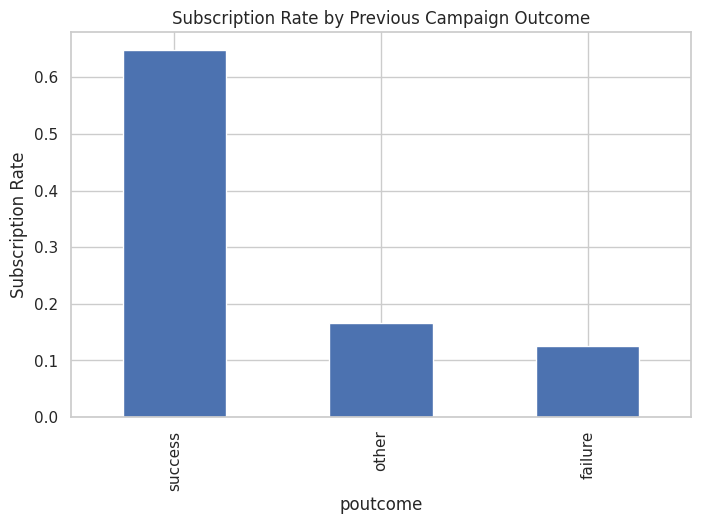

In [46]:
poutcome_rate = (
    df.groupby("poutcome")["y_binary"]
    .mean()
    .sort_values(ascending=False)
)

poutcome_rate.plot(kind="bar")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.show()


### Contact Type and Timing

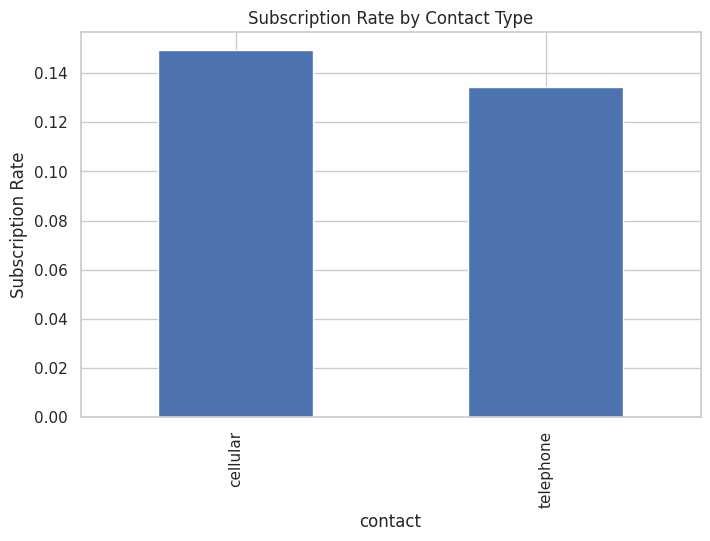

In [47]:
contact_rate = df.groupby("contact")["y_binary"].mean()
contact_rate.plot(kind="bar")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Contact Type")
plt.show()


## Month and Day

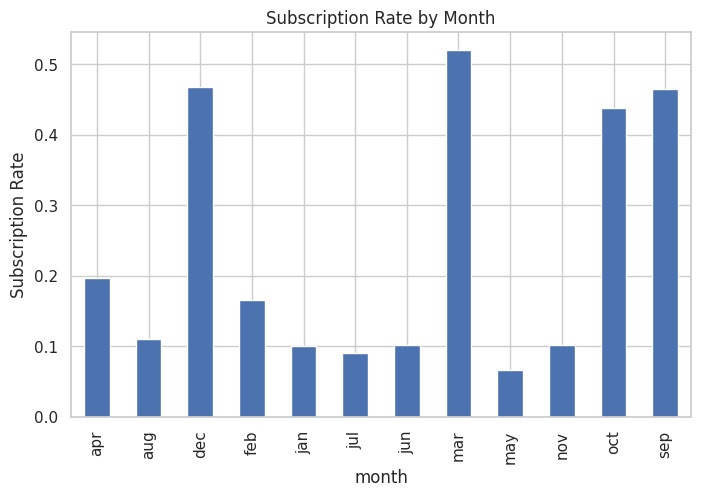

In [48]:
month_rate = df.groupby("month")["y_binary"].mean()
month_rate.plot(kind="bar")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Month")
plt.show()


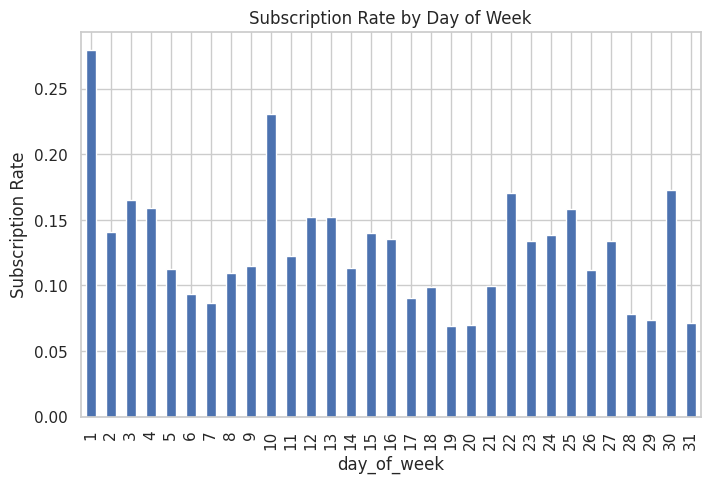

In [49]:
day_rate = df.groupby("day_of_week")["y_binary"].mean()
day_rate.plot(kind="bar")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Day of Week")
plt.show()


## Missing Value Analaysis

In [40]:
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct[missing_pct > 0]


poutcome     0.817478
contact      0.287983
education    0.041074
job          0.006370
age_bin      0.000265
dtype: float64

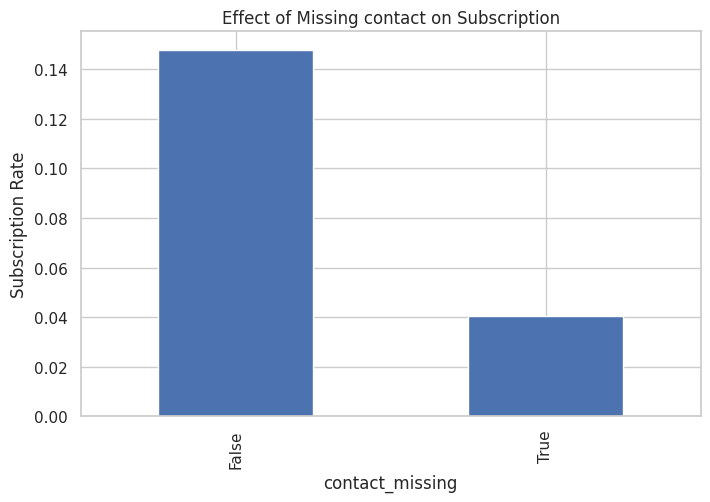

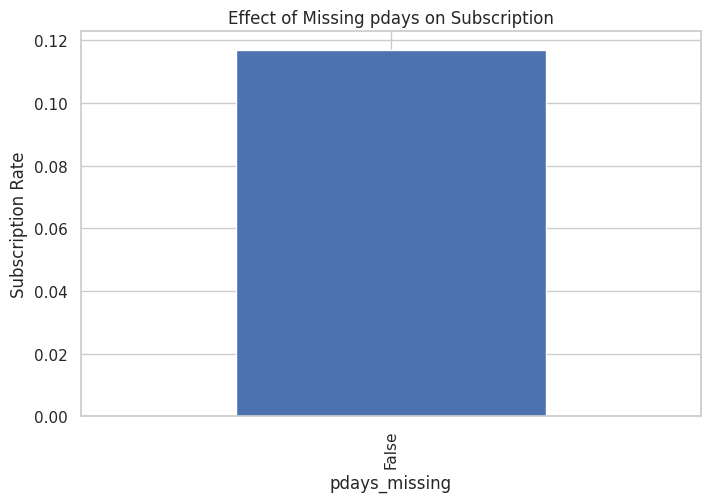

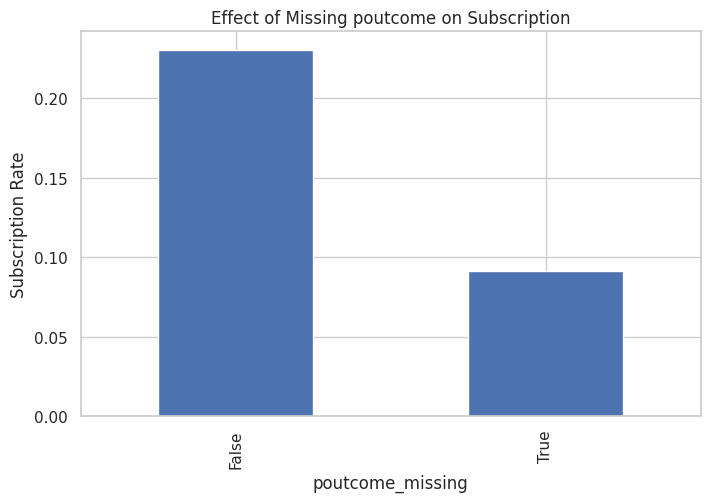

In [41]:
for col in ["contact", "pdays", "poutcome"]:
    df[f"{col}_missing"] = df[col].isna()
    rate = df.groupby(f"{col}_missing")["y_binary"].mean()
    rate.plot(kind="bar")
    plt.title(f"Effect of Missing {col} on Subscription")
    plt.ylabel("Subscription Rate")
    plt.show()

## Correlation heatmap

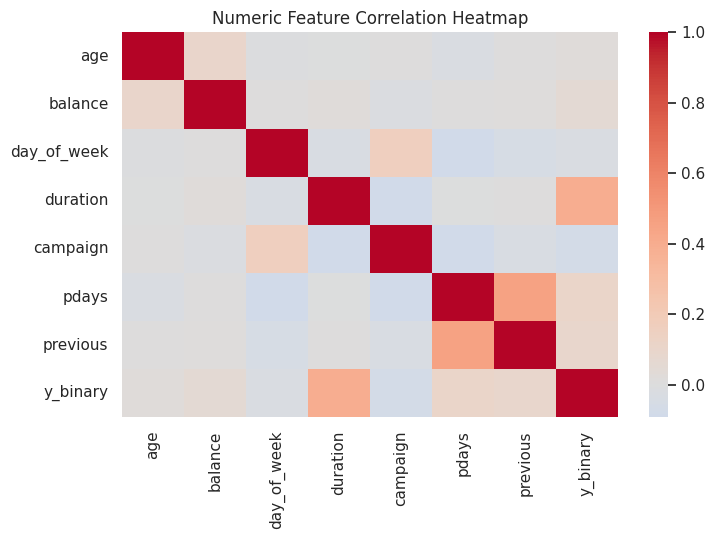

In [39]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

corr = df[num_cols].corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Heatmap")
plt.show()


## Feature Engineering